In [12]:
import pynapple as nap
import numpy as np
import pandas as pd
from monkeypaw.io import nap_load_data,get_spike_count,get_behav,get_info

# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-5-Animals-3&4\sub-Dataset-5-Animals-3&4.nwb"
nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-3-Animals-1-to-4\sub-Dataset-3-Animals-1-to-4.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-4-Animal-3-sess-1-to-6\sub-Dataset-4-Animal-3-sess-1-to-6.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-5-Animals-2-ses-20-to-39\sub-Dataset-5-Animals-2-ses-20-to-39.nwb"
data = nap_load_data(nwb_path)

# actually load in data
spike_count = get_spike_count(data)
behav = get_behav(data)
info = get_info(data)

Original keys: ['spikes_counts', 'trial_id', 'session', 'datasetID', 'animal', 'result', 'EventTarget_Onset', 'EventMovement_start', 'EventGo_cue', 'target_dir', 'hand_vel_y', 'hand_vel_x', 'date', 'brain_region']


In [13]:
behav.columns

Index(['EventGo_cue', 'EventTarget_Onset', 'target_ID', 'target_dir', 'result',
       'cursor_pos_x', 'cursor_pos_y', 'cursor_vel_x', 'cursor_vel_y',
       'cursor_acc_x', 'cursor_acc_y'],
      dtype='str')

In [14]:
info = get_info(data)
info.as_dataframe()

,trial_id,animal,datasetID,session,brain_region
0.00,1,1,3,1,M1
0.03,1,1,3,1,M1
0.06,1,1,3,1,M1
0.09,1,1,3,1,M1
0.12,1,1,3,1,M1
...,...,...,...,...,...
32235.12,465,3,3,3,Area2
32235.15,465,3,3,3,Area2
32235.18,465,3,3,3,Area2
32235.21,465,3,3,3,Area2


# Take 1 session and 1 animal from the output of compute_perievent.

In [15]:
# Take 1 session and 1 animal from the output of compute_perievent.
from monkeypaw.proc import compute_perievent, get_index_from_info
all_peth = compute_perievent(spike_count, behav, info, win = (-1,2))

# Here we give an example to use the go cue events. (target cue is also computed just replace "go" with "target")
idx_go = get_index_from_info(all_peth["info_go"], by = ["animal","session"])

print(f"Keys from compute_perievent: {all_peth.keys()}")
print(f"(animal, session) key to index for events: {idx_go.keys()}")

Keys from compute_perievent: dict_keys(['info_go', 'ev_go', 'peth_go', 'bpeth_go', 'bpeth_go_columns', 'info_target', 'ev_target', 'peth_target', 'bpeth_target', 'bpeth_target_columns'])
(animal, session) key to index for events: dict_keys([(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (3, 1), (3, 2), (3, 3), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6)])


Shape of peth for animal 1 session 1: 100 timestamps, 1038 events, 121 units


c:\Users\lilytong\.conda\envs\monkeypaw\Lib\site-packages\pynapple\core\time_series.py:329: RuntimeWarning: Mean of empty slice
  out = func._implementation(*new_args, **kwargs)


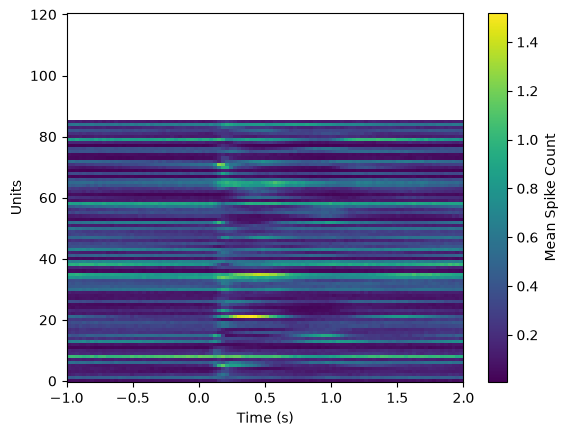

In [19]:
# Say if we want animal 1 and session 1, we can get the index for that animal and session. 
animal = 1
session = 1
idx = idx_go[(animal, session)]

# get the correponding event for animal 1 session 1
peth = all_peth["peth_go"][:,idx,:]
ev_info = all_peth["info_go"].iloc[idx]
# the peth will be a 3D array with shape (n_timestamps, n_events, n_units). We can sum across the events to get the total spike count for each neuron across all events.
n_timestamps, n_events, n_units = peth.shape
print(f"Shape of peth for animal {animal} session {session}: {n_timestamps} timestamps, {n_events} events, {n_units} units")

# with this we can plot mean spike count across trials for each unit
import matplotlib.pyplot as plt
t = peth.times()
plt.pcolormesh(t, np.arange(n_units), np.nanmean(peth, axis=1).data().T)
plt.xlabel("Time (s)")
plt.ylabel("Units")
plt.colorbar(label="Mean Spike Count")

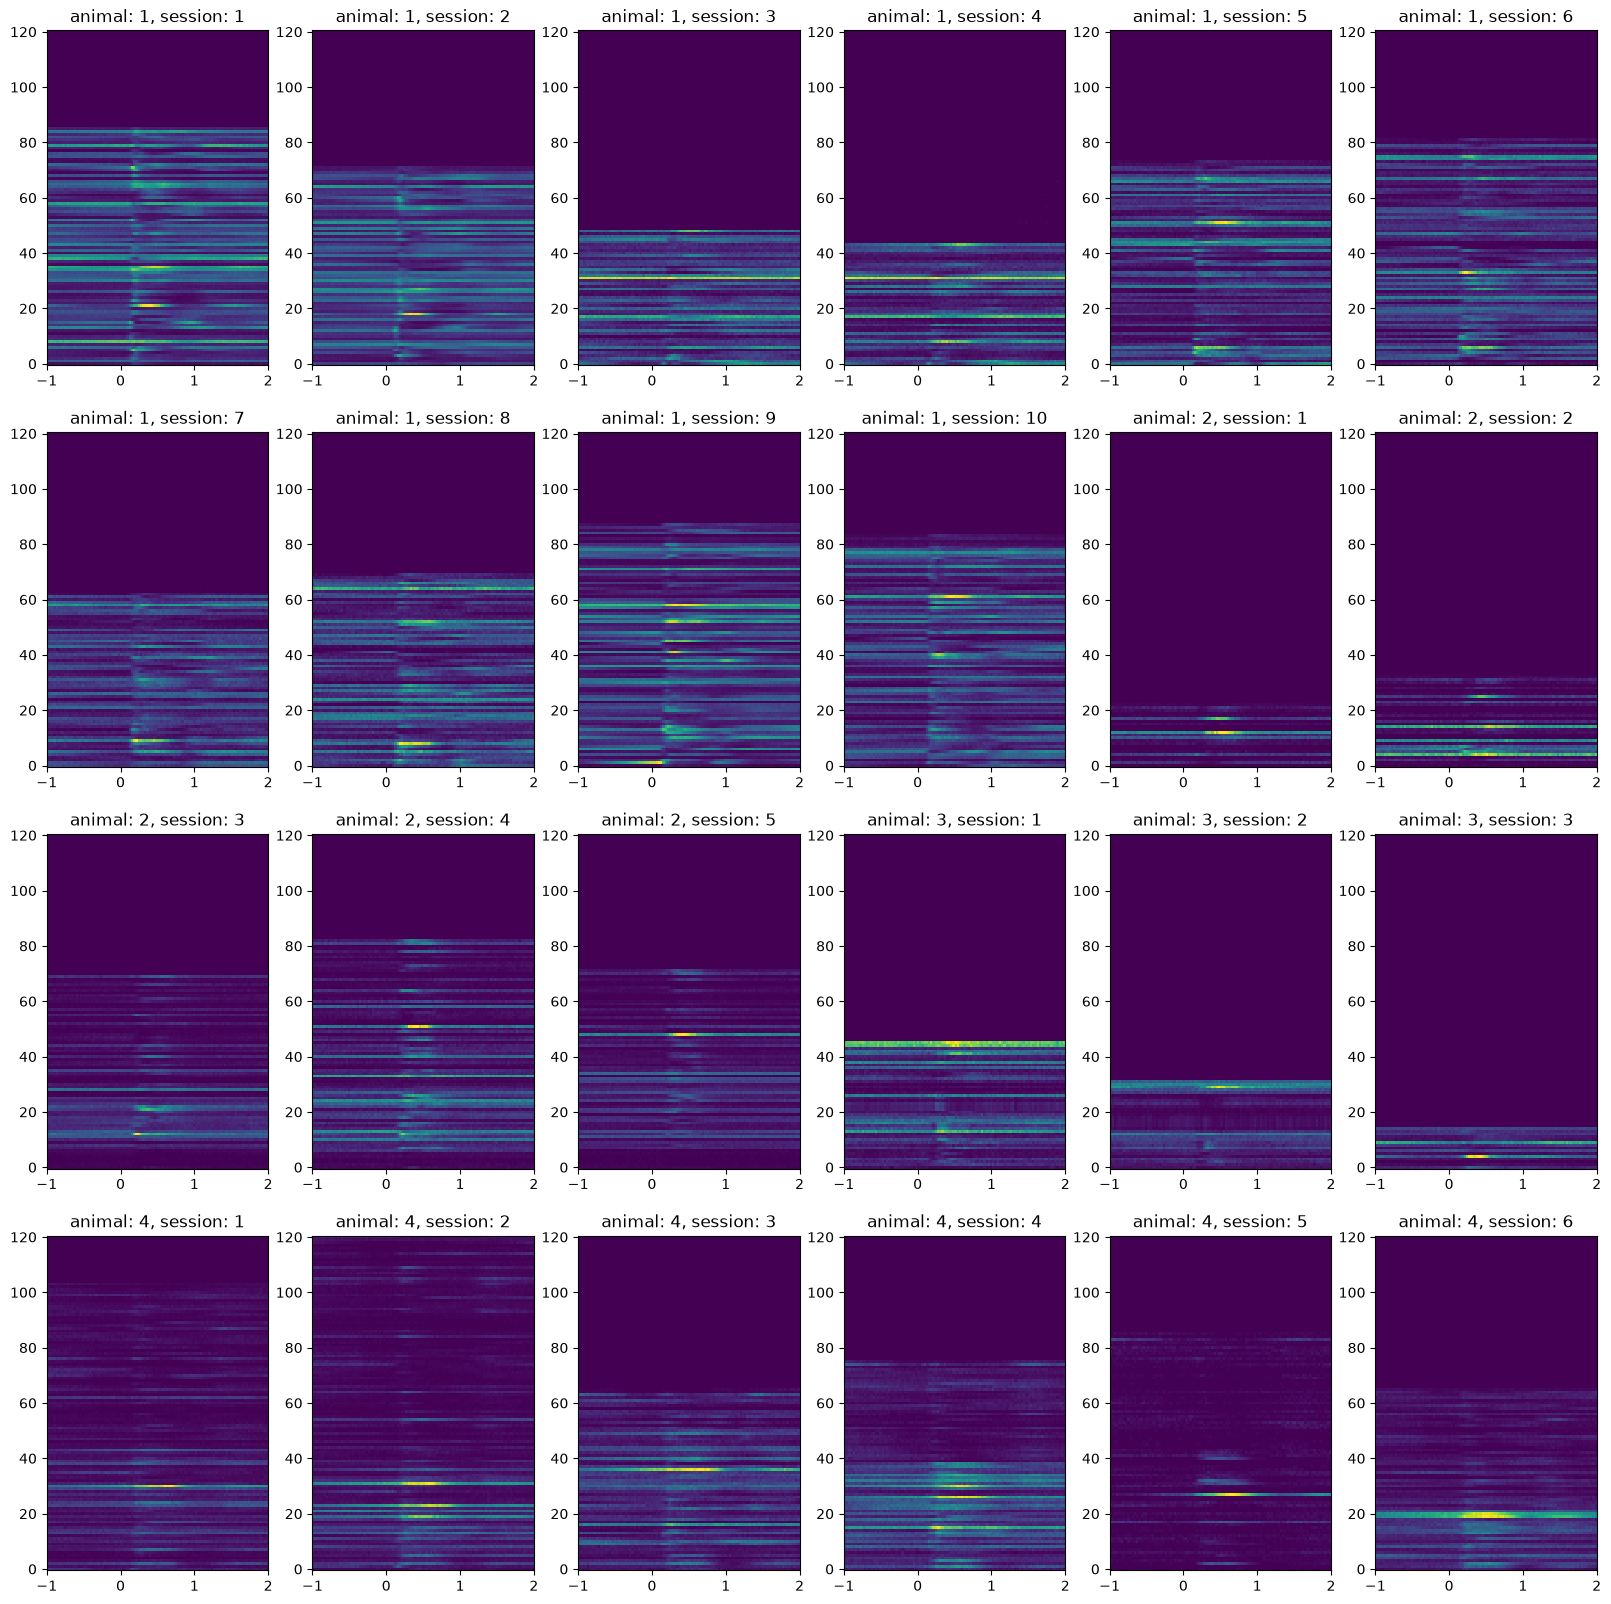

In [ ]:
# Loop through all animals and session, plot each session separately.
from monkeypaw.proc import get_index_from_info
idx_go = get_index_from_info(all_peth["info_go"], by = ["animal","session"])

import matplotlib.pyplot as plt

fig,ax = plt.subplots(4,6,figsize=(20,20))
for i, (name, idx) in enumerate(idx_go.items()):
    if i >= 24:
        break
    ax_i = ax[i//6,i%6]
    ev_go_i = all_peth["ev_go"][idx]
    peth_i = all_peth["peth_go"][:,idx,:]
    count = np.nansum(peth_i,axis=1)
    t = all_peth["peth_go"].times()
    ax_i.pcolormesh(t, np.arange(count.shape[1]), count.values.T)
    ax_i.set_title(f"animal: {name[0]}, session: {name[1]}")

In [43]:
key_cols = ["datasetID","animal", "session", "trial_id"]
comparison = (
    info_go[key_cols]
    .drop_duplicates()
    .merge(
        info_target[key_cols].drop_duplicates(),
        on=key_cols,
        how="outer",
        indicator=True,
    )
)
in_go_not_target = comparison.loc[
    comparison["_merge"] == "left_only",
    key_cols,
]
in_target_not_go = comparison.loc[
    comparison["_merge"] == "right_only",
    key_cols,
]
in_both = comparison.loc[
    comparison["_merge"] == "both",
    key_cols,
]

In [44]:
print(f"Number of trials in Go but not Target: {len(in_go_not_target)}")
print(f"Number of trials in Target but not Go: {len(in_target_not_go)}")
print(f"Number of trials in both datasets: {len(in_both)}")

Number of trials in Go but not Target: 2321
Number of trials in Target but not Go: 1
Number of trials in both datasets: 5624


In [47]:
in_go_not_target["animal"].value_counts()

animal
2    1253
3    1068
Name: count, dtype: int64

In [45]:
in_target_not_go

,datasetID,animal,session,trial_id
5969,3,3,2,49


In [38]:
in_both

,datasetID,animal,session,trial_id
0,5,2,20,1
1,5,2,20,3
2,5,2,20,4
3,5,2,20,5
4,5,2,20,6
...,...,...,...,...
4496,5,2,39,317
4497,5,2,39,319
4498,5,2,39,320
4499,5,2,39,324
